In [2]:
%matplotlib inline

import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import yaml
import os

In [3]:
os.makedirs('../plots/shape_functions', exist_ok=True)

with open('../config/params.yaml', 'r') as f:
    config = yaml.safe_load(f)

rho_s = config['dark_matter']['rho_s']
r_s = config['dark_matter']['r_s']
C1 = config['wormhole']['C1']
Q = config['wormhole']['Q']

In [4]:
from src.dark_matter import DarkMatterProfile
from src.shape_function import ShapeFunction

dm = DarkMatterProfile(rho_s, r_s)
sf = ShapeFunction(rho_s, r_s, C1, Q)

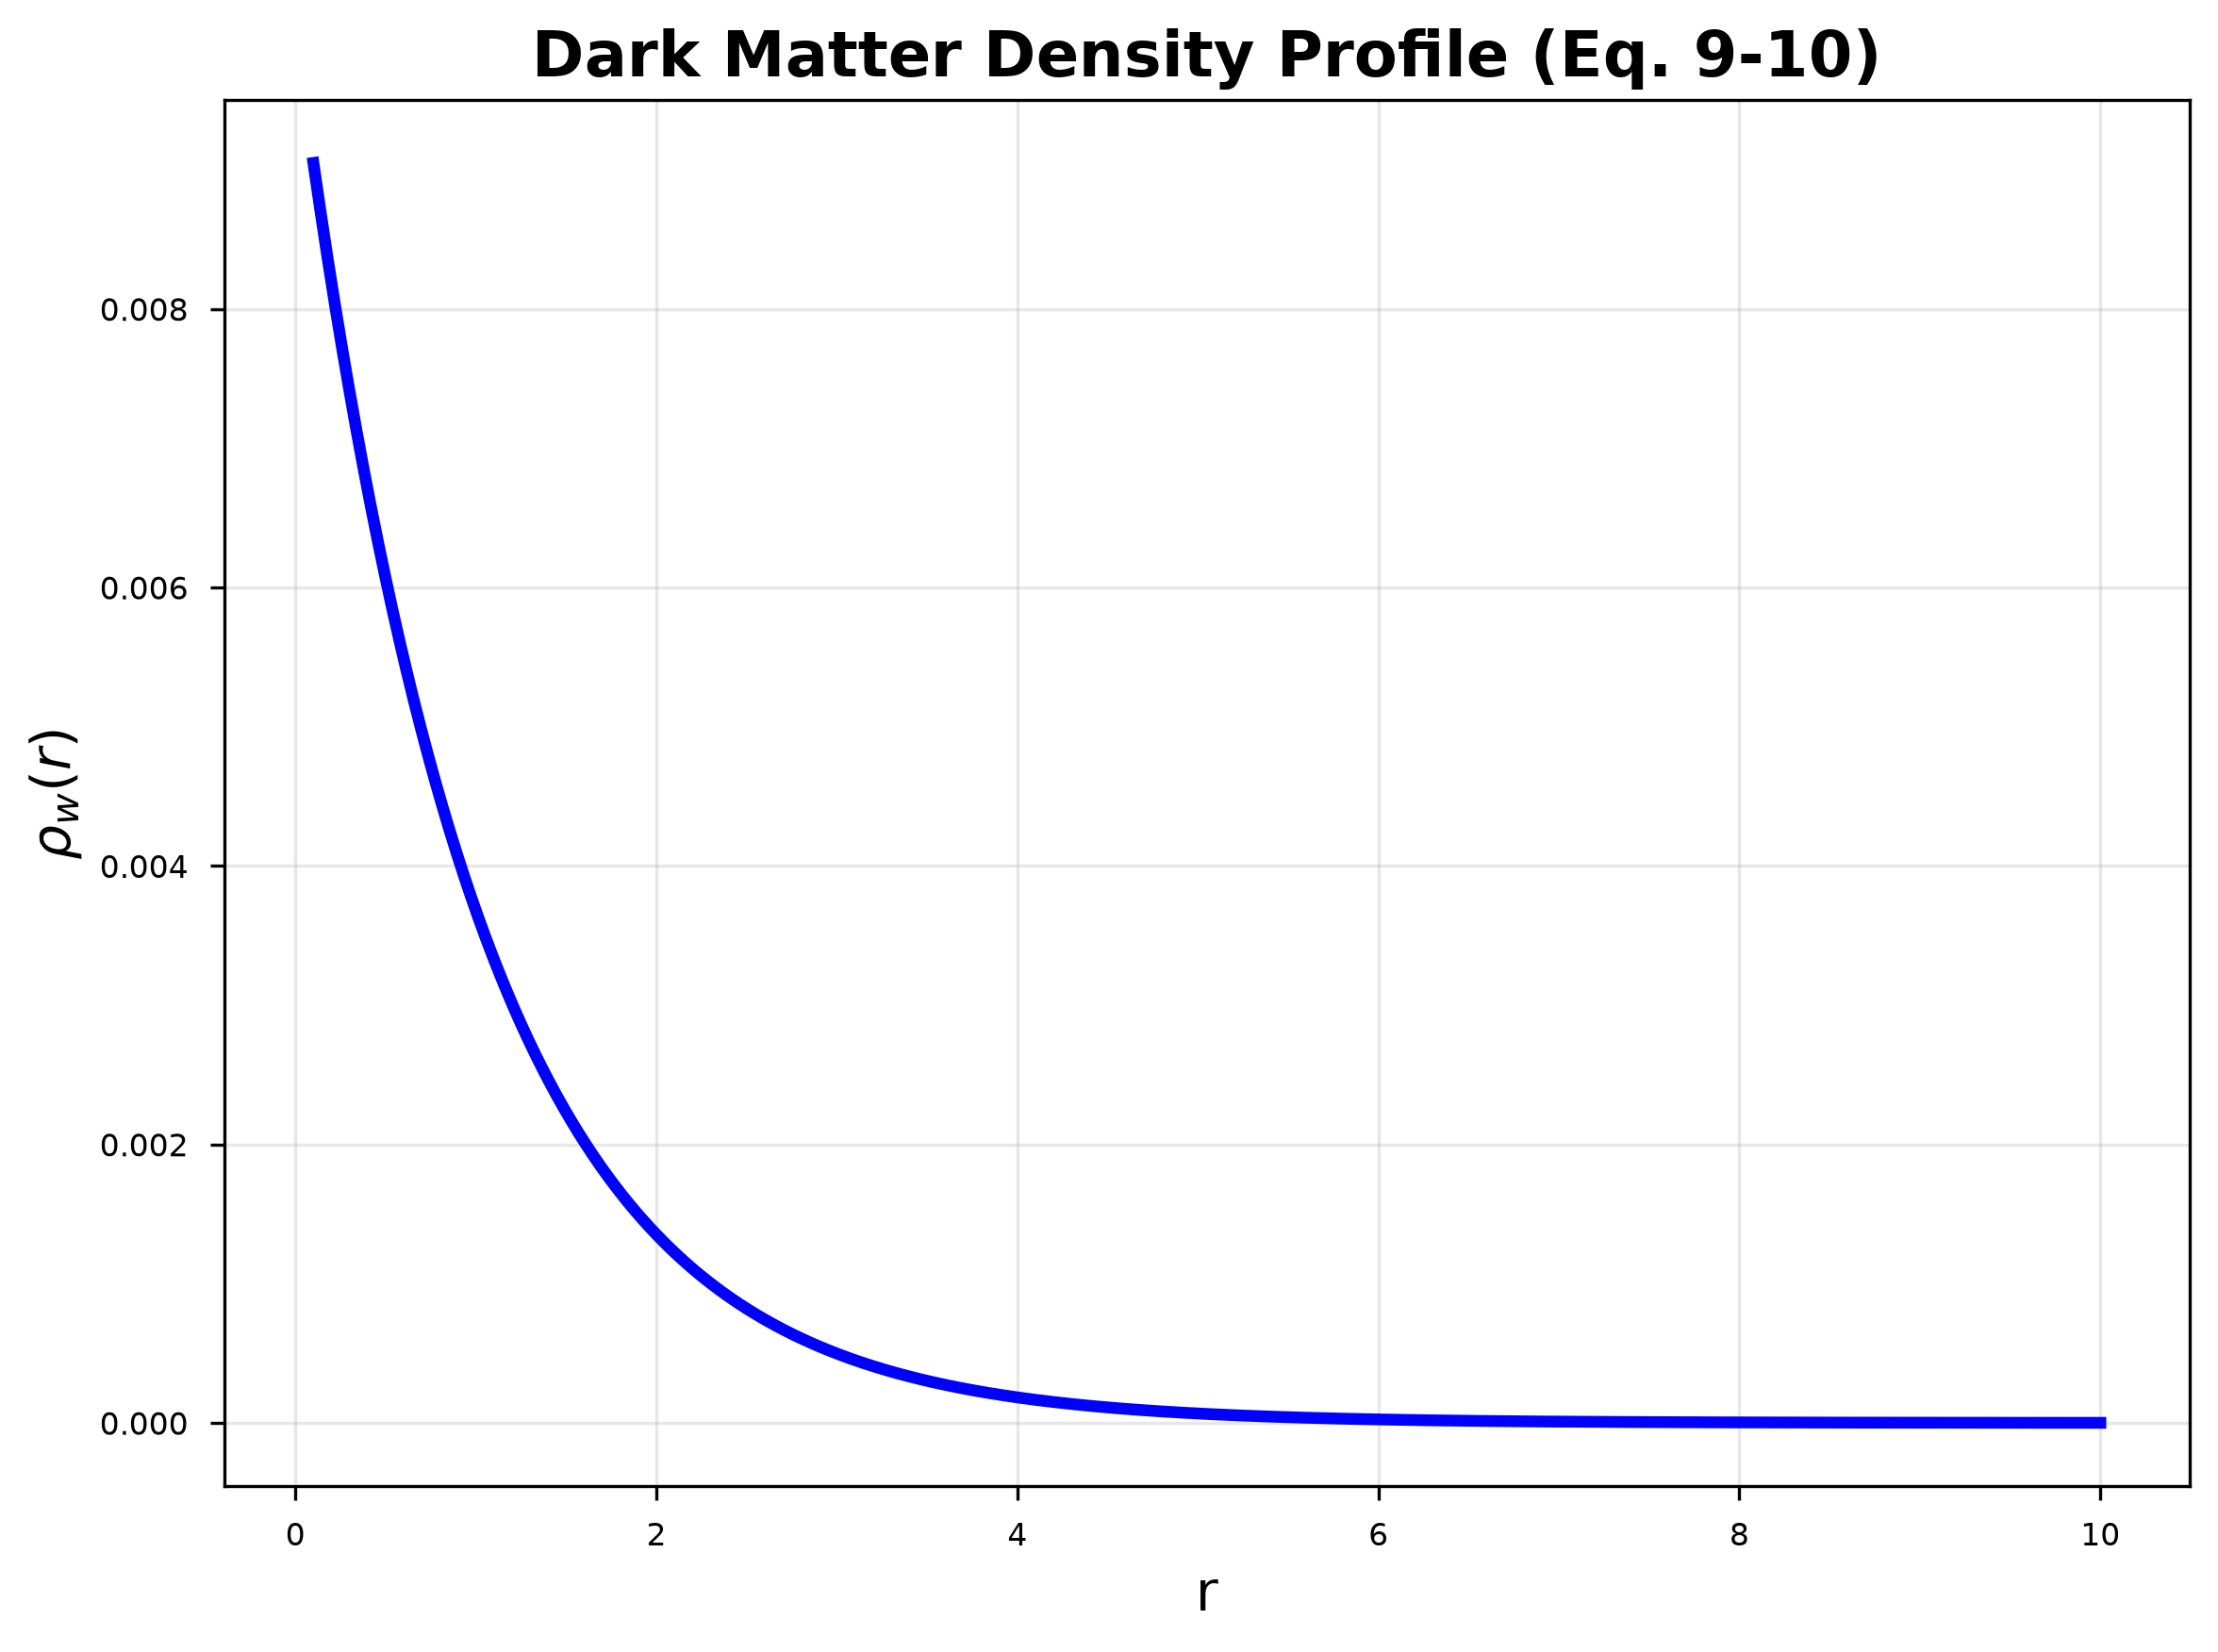

In [5]:
r_values = np.linspace(0.1, 10, 1000)
rho_w = dm.density(r_values)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(r_values, rho_w, 'b-', linewidth=3)
ax.set_xlabel('r', fontsize=14)
ax.set_ylabel(r'$\rho_w(r)$', fontsize=14)
ax.set_title('Dark Matter Density Profile (Eq. 9-10)', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/shape_functions/dark_matter_density.png', dpi=300, bbox_inches='tight')
plt.show()

Throat radius: 0.5047599043077949


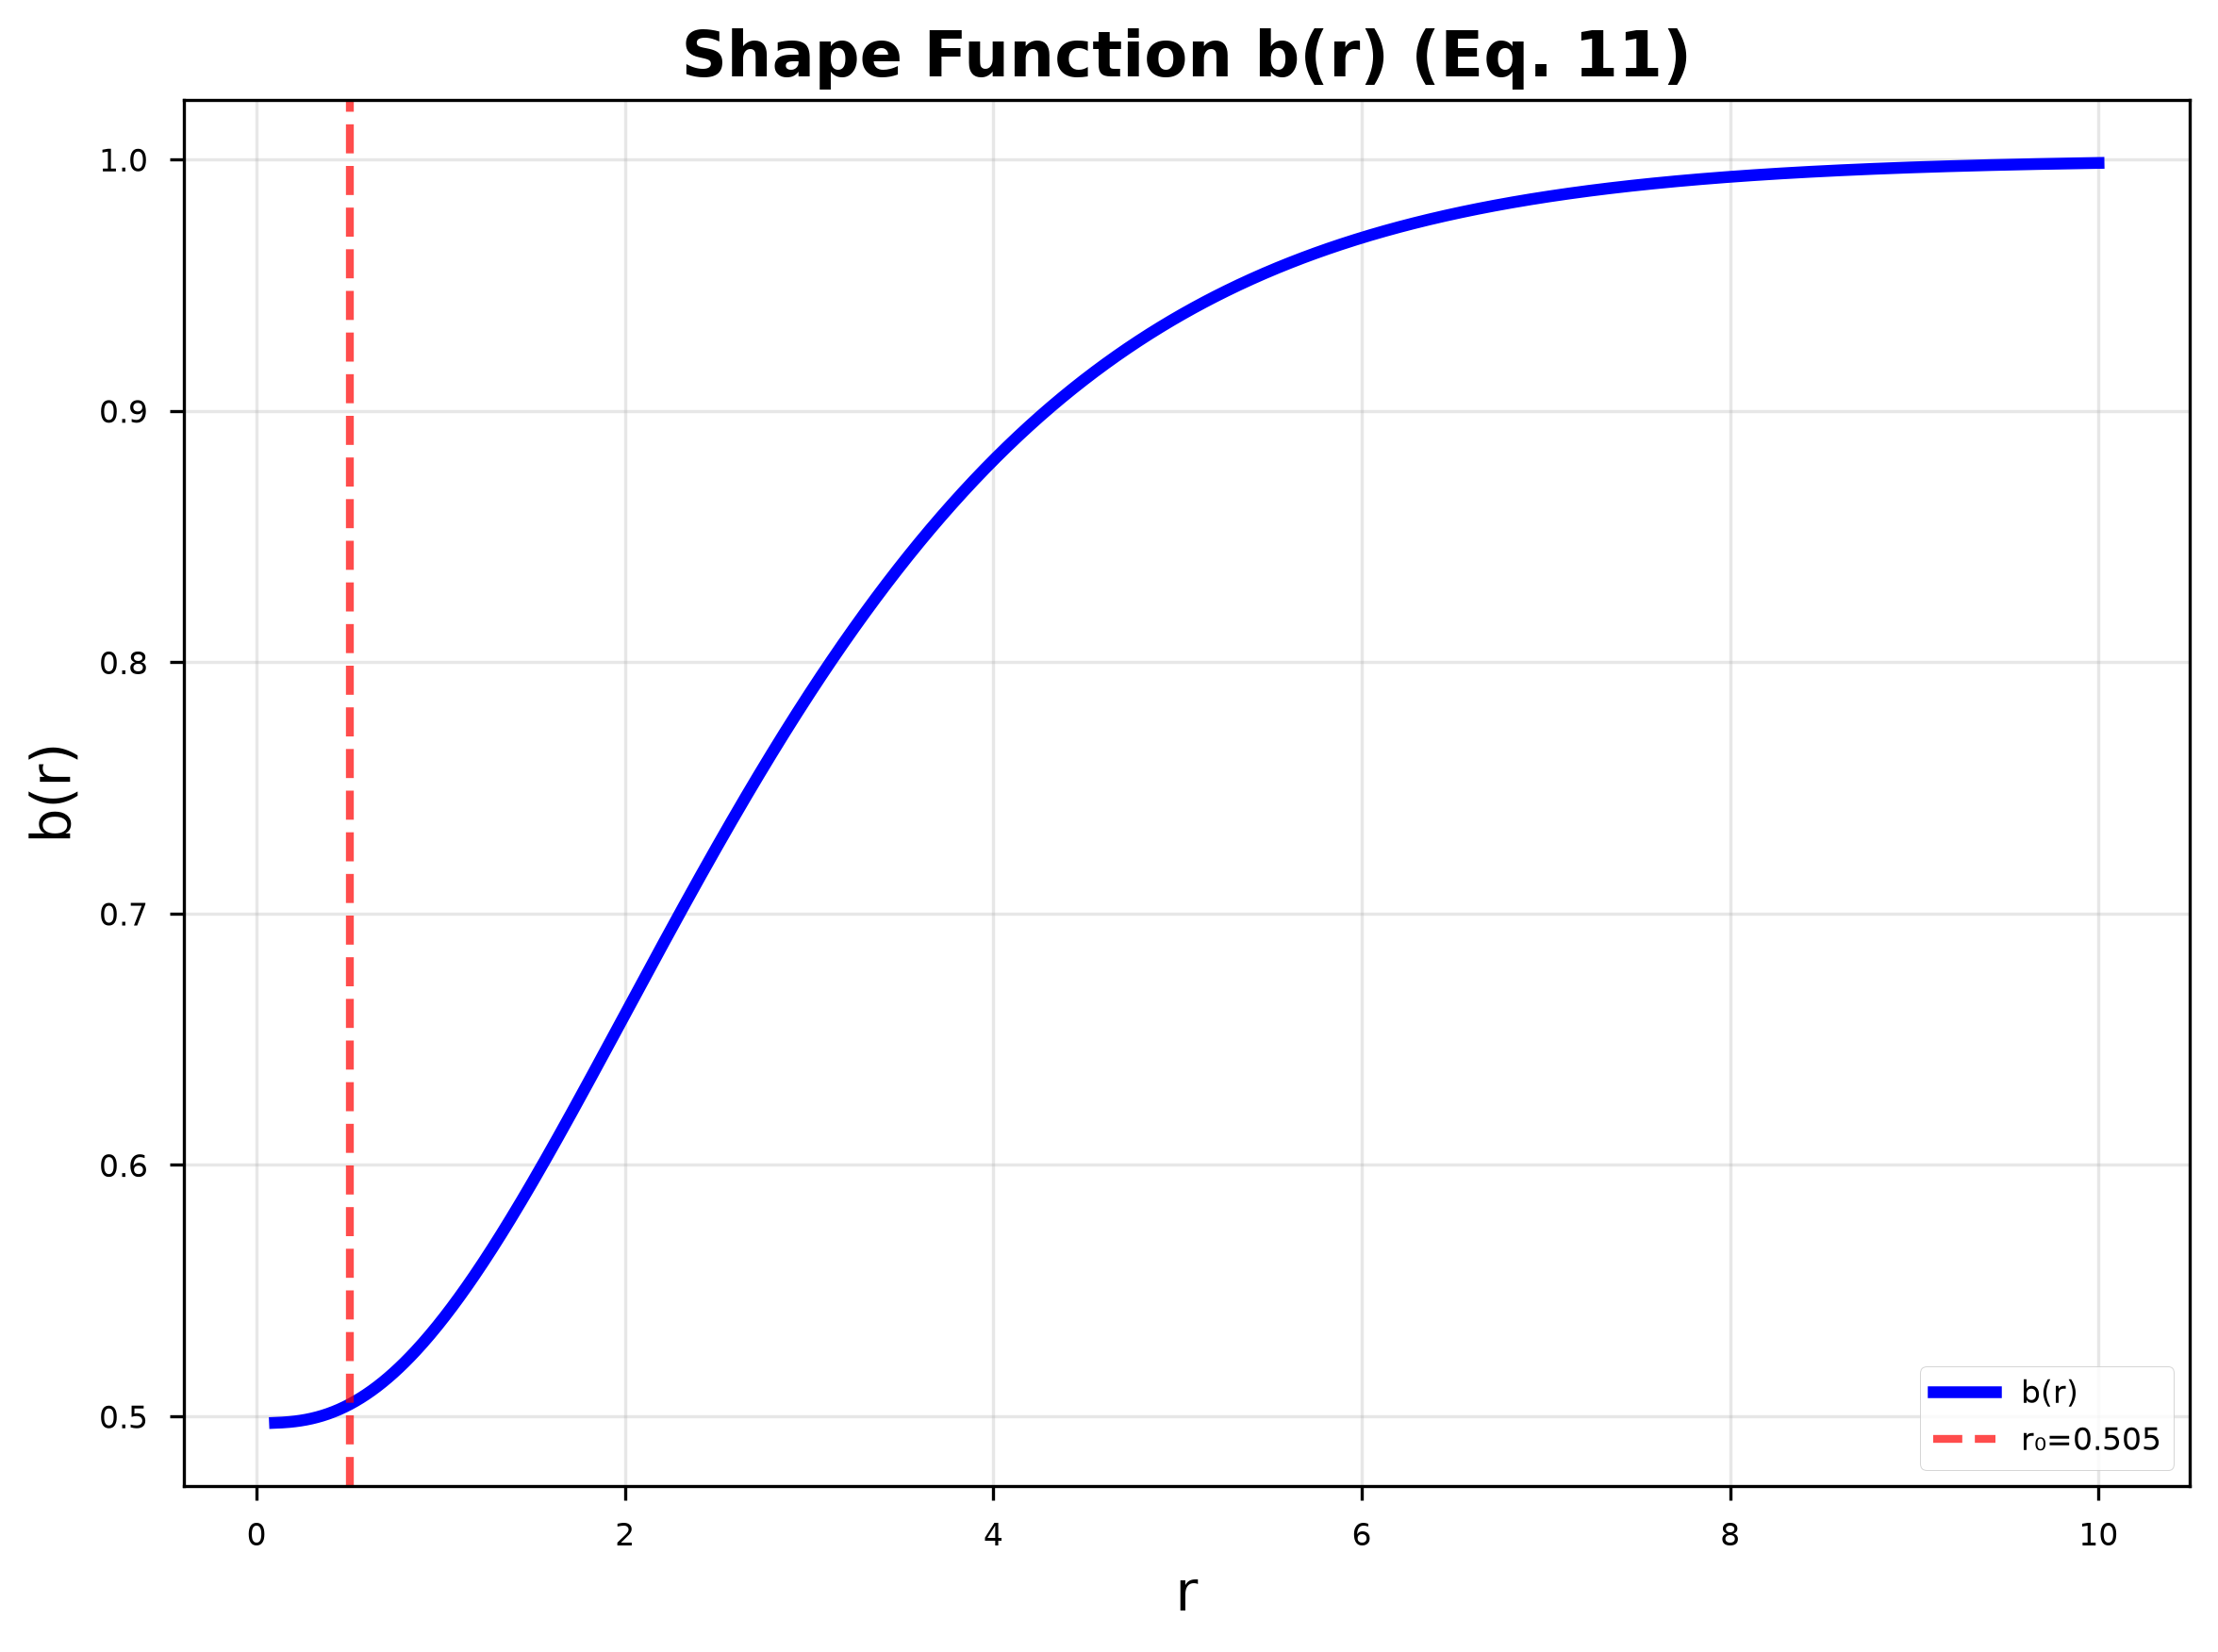

In [6]:
b_vals = sf.b(r_values)

# Find throat
throat = sf.find_throat()
print(f"Throat radius: {throat}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(r_values, b_vals, 'b-', linewidth=3, label='b(r)')
if throat:
    ax.axvline(x=throat, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'r₀={throat:.3f}')
ax.set_xlabel('r', fontsize=14)
ax.set_ylabel('b(r)', fontsize=14)
ax.set_title('Shape Function b(r) (Eq. 11)', fontsize=16, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/shape_functions/shape_function_b.png', dpi=300, bbox_inches='tight')
plt.show()

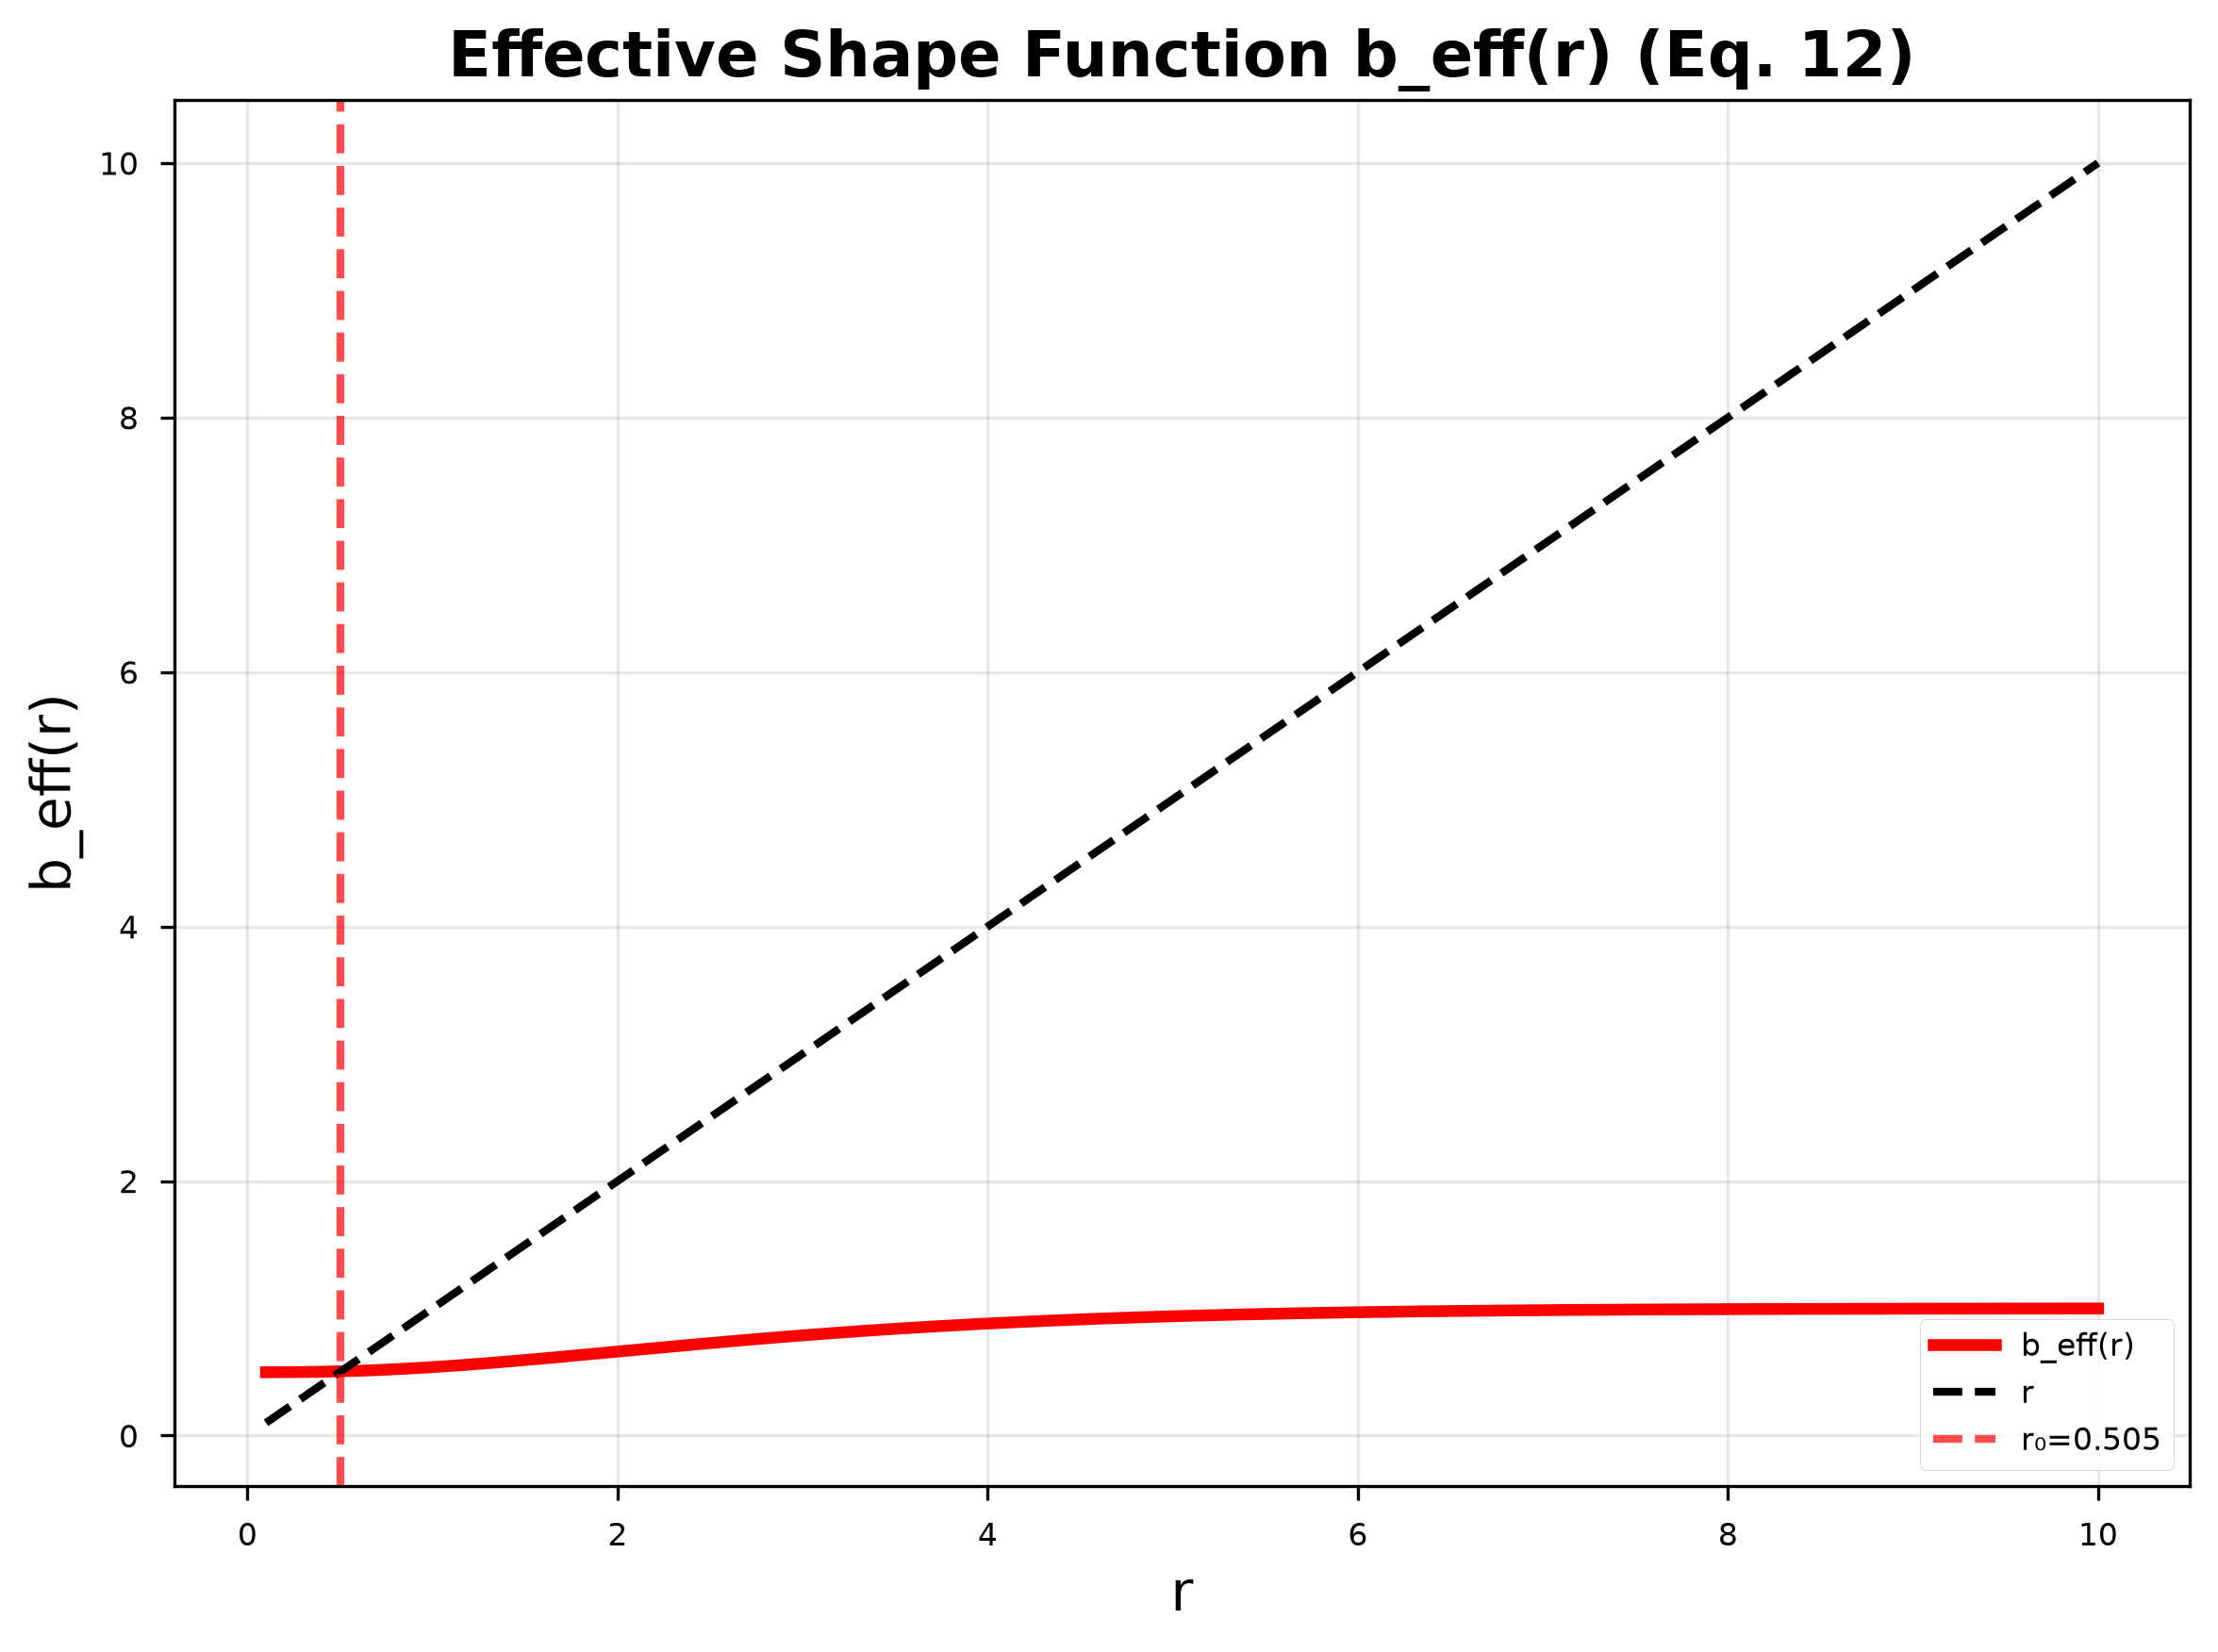

In [7]:
b_eff_vals = sf.b_eff(r_values)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(r_values, b_eff_vals, 'r-', linewidth=3, label='b_eff(r)')
ax.plot(r_values, r_values, 'k--', linewidth=2, label='r')
if throat:
    ax.axvline(x=throat, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'r₀={throat:.3f}')
ax.set_xlabel('r', fontsize=14)
ax.set_ylabel('b_eff(r)', fontsize=14)
ax.set_title('Effective Shape Function b_eff(r) (Eq. 12)', fontsize=16, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/shape_functions/effective_shape_function.png', dpi=300, bbox_inches='tight')
plt.show()

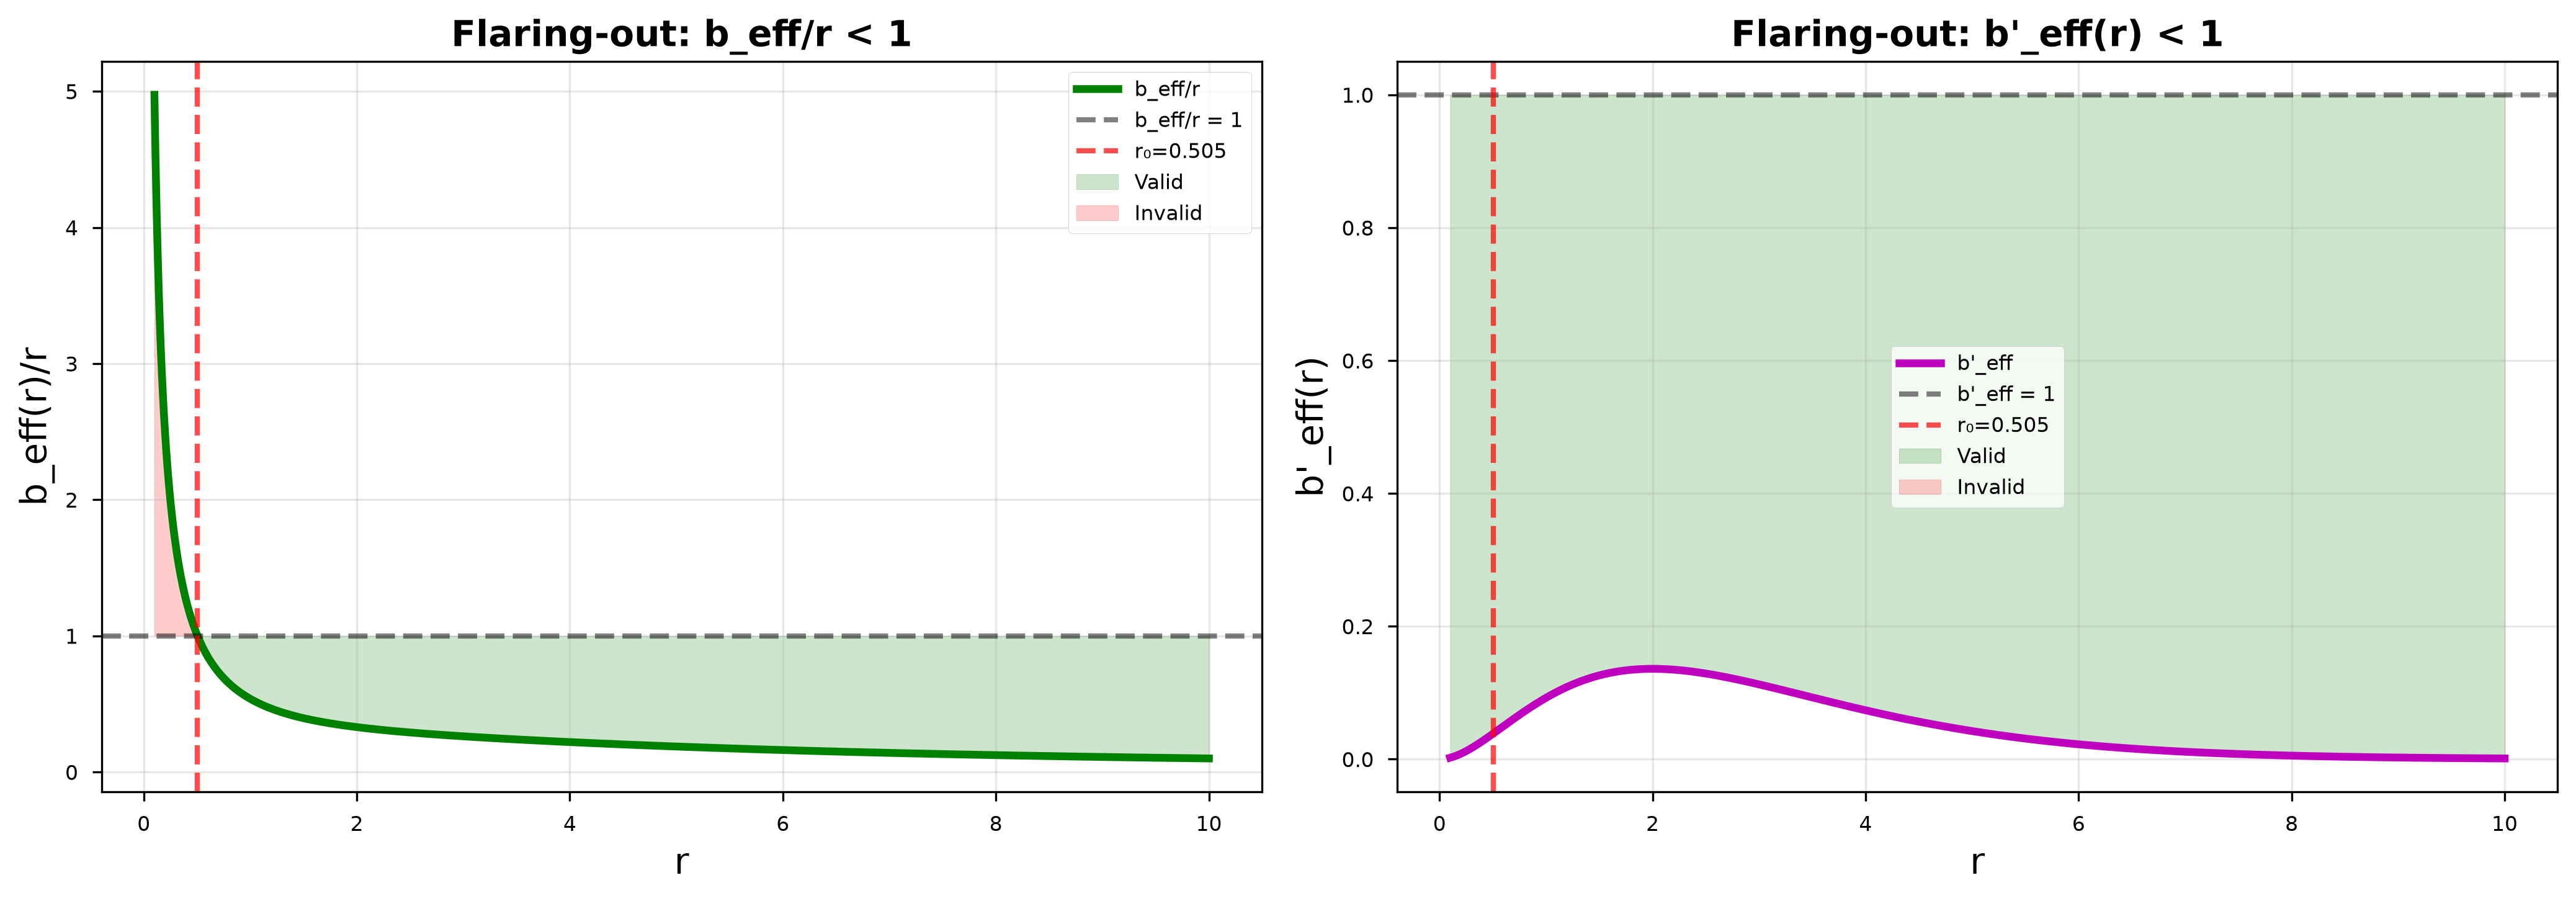

In [8]:

ratio = b_eff_vals / r_values
b_eff_prime = sf.b_eff_prime(r_values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: b_eff(r)/r
axes[0].plot(r_values, ratio, 'g-', linewidth=3, label='b_eff/r')
axes[0].axhline(y=1, color='k', linestyle='--', linewidth=2, alpha=0.5, label='b_eff/r = 1')
if throat:
    axes[0].axvline(x=throat, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'r₀={throat:.3f}')
axes[0].fill_between(r_values, ratio, 1, where=(ratio < 1), color='green', alpha=0.2, label='Valid')
axes[0].fill_between(r_values, ratio, 1, where=(ratio > 1), color='red', alpha=0.2, label='Invalid')
axes[0].set_xlabel('r', fontsize=14)
axes[0].set_ylabel('b_eff(r)/r', fontsize=14)
axes[0].set_title('Flaring-out: b_eff/r < 1', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: b_eff'(r)
axes[1].plot(r_values, b_eff_prime, 'm-', linewidth=3, label="b'_eff")
axes[1].axhline(y=1, color='k', linestyle='--', linewidth=2, alpha=0.5, label="b'_eff = 1")
if throat:
    axes[1].axvline(x=throat, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'r₀={throat:.3f}')
axes[1].fill_between(r_values, b_eff_prime, 1, where=(b_eff_prime < 1), color='green', alpha=0.2, label='Valid')
axes[1].fill_between(r_values, b_eff_prime, 1, where=(b_eff_prime > 1), color='red', alpha=0.2, label='Invalid')
axes[1].set_xlabel('r', fontsize=14)
axes[1].set_ylabel("b'_eff(r)", fontsize=14)
axes[1].set_title("Flaring-out: b'_eff(r) < 1", fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/shape_functions/flaring_out_condition.png', dpi=300, bbox_inches='tight')
plt.show()

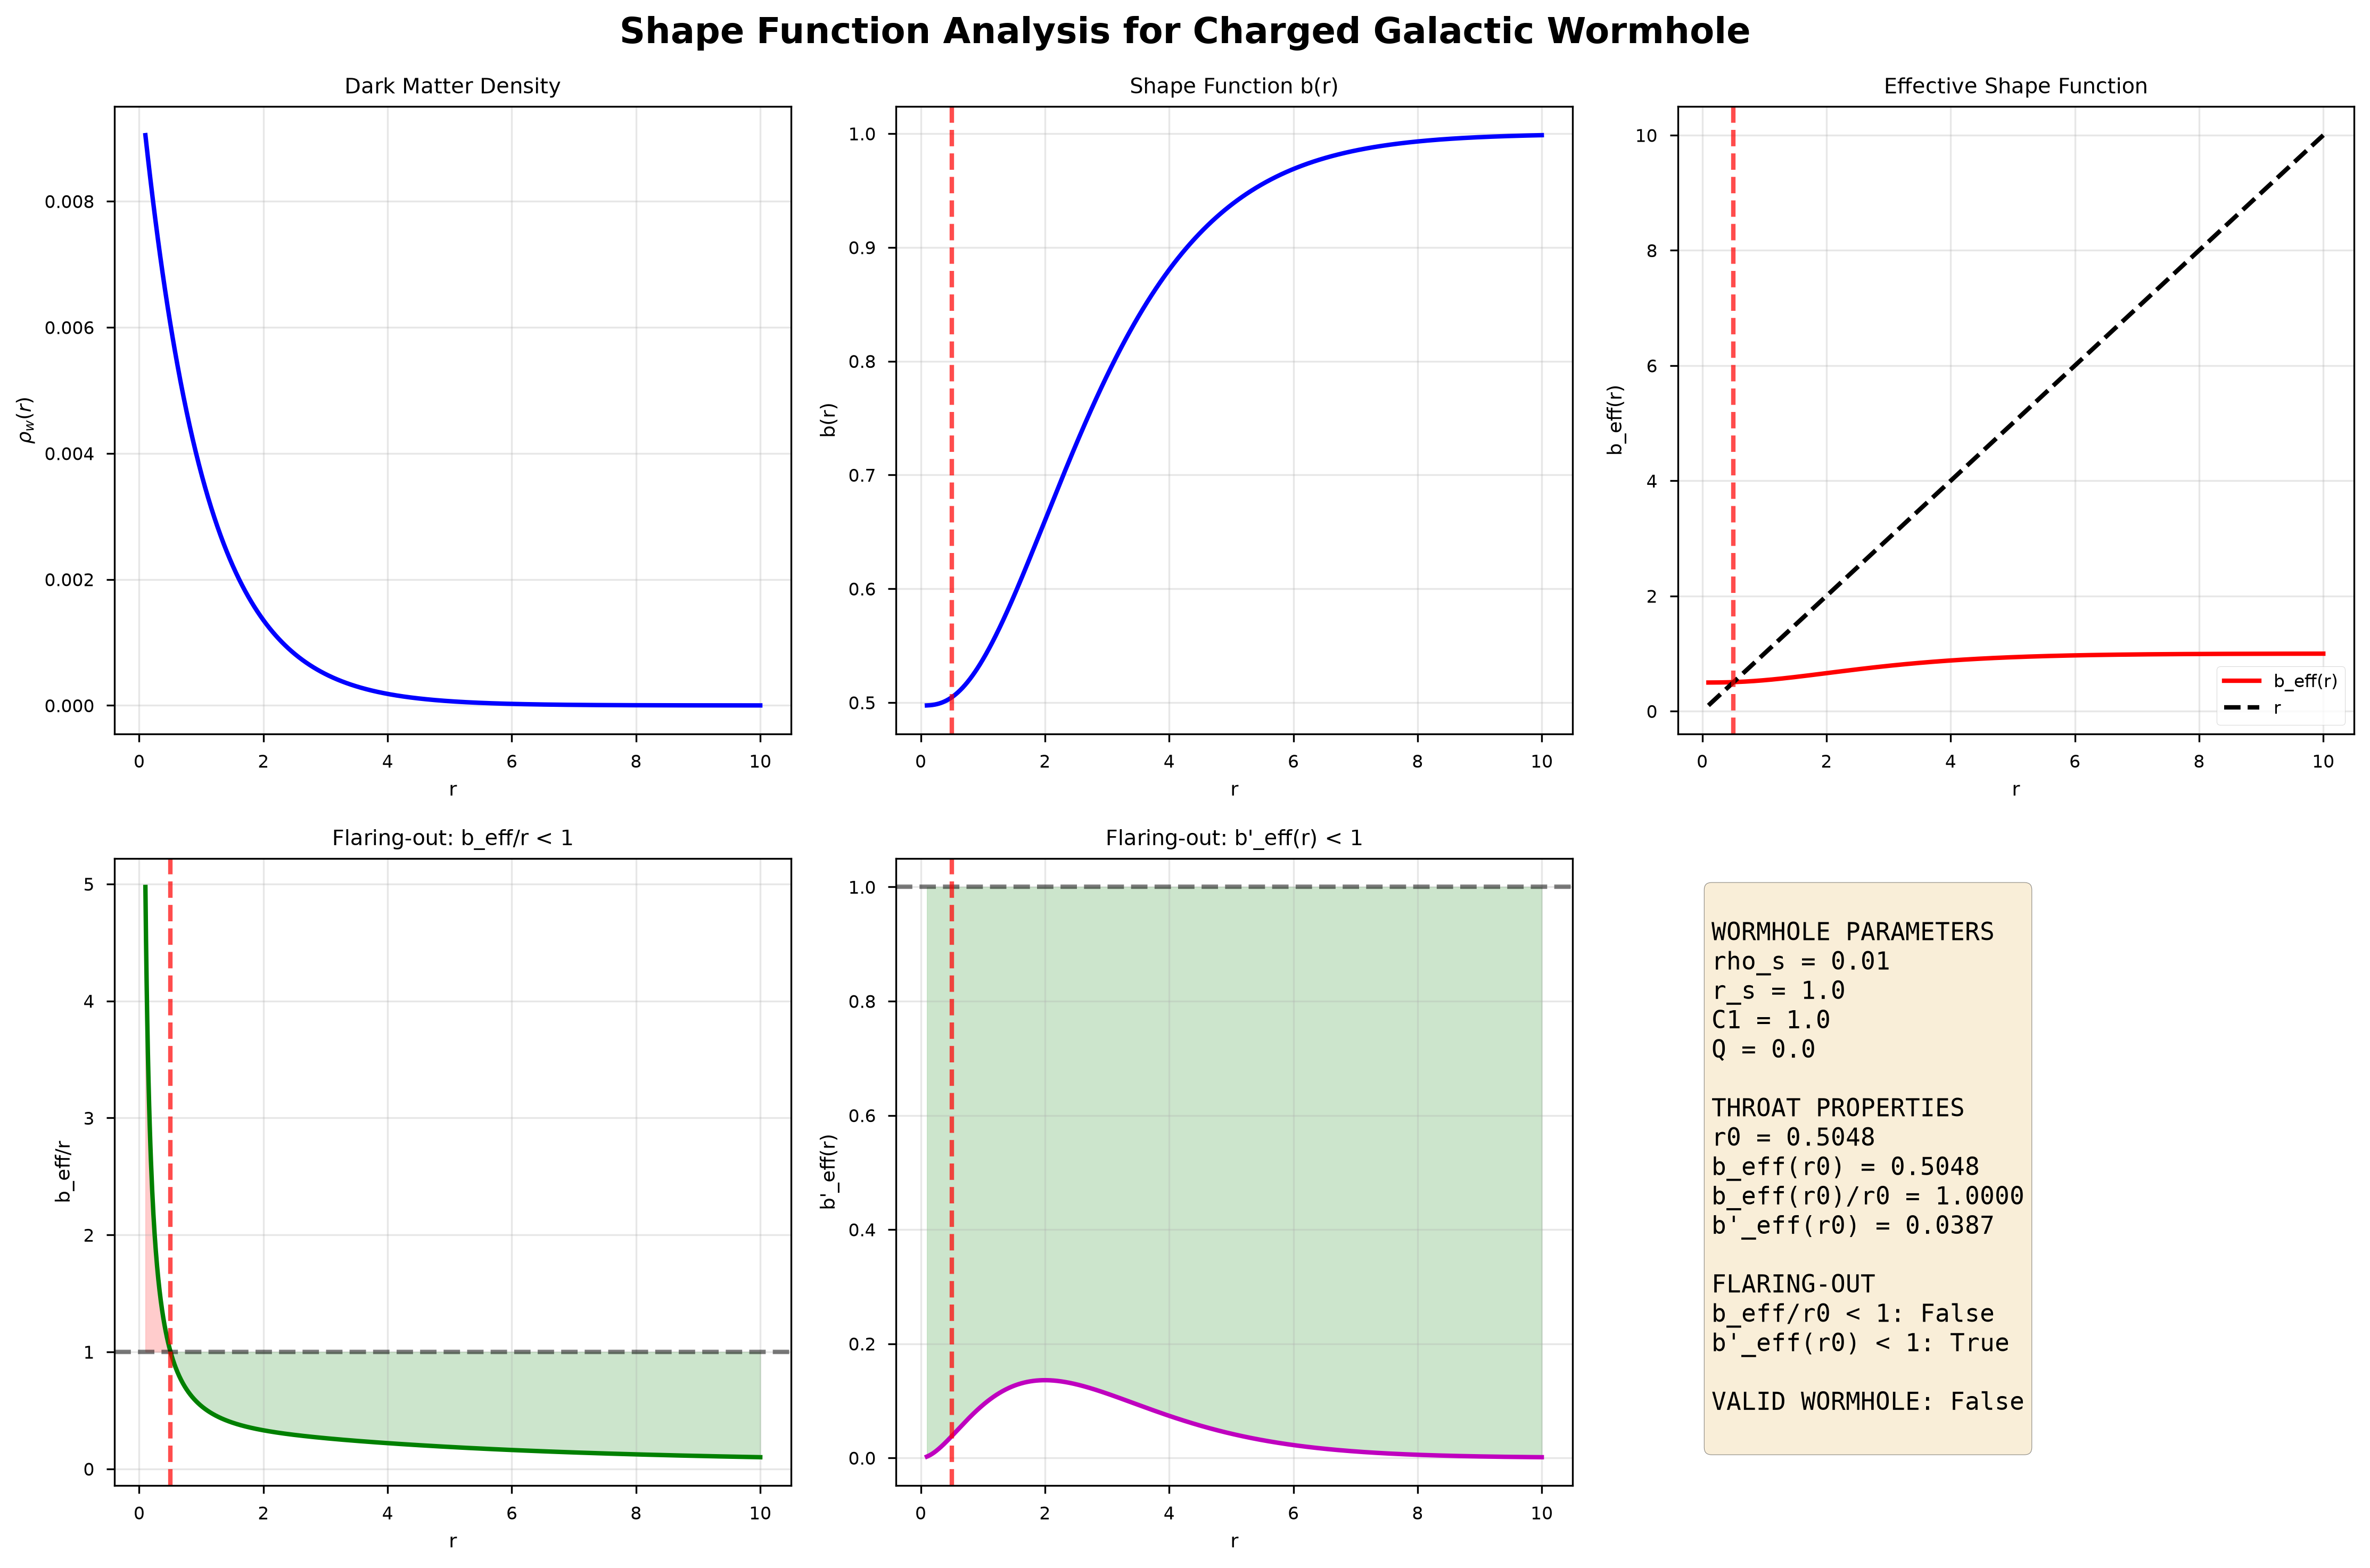

In [12]:

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Shape Function Analysis for Charged Galactic Wormhole', fontsize=16, fontweight='bold')

# Panel 1: Dark matter density
axes[0, 0].plot(r_values, rho_w, 'b-', linewidth=2)
axes[0, 0].set_xlabel('r')
axes[0, 0].set_ylabel(r'$\rho_w(r)$')
axes[0, 0].set_title('Dark Matter Density')
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Shape function b(r)
axes[0, 1].plot(r_values, b_vals, 'b-', linewidth=2)
if throat:
    axes[0, 1].axvline(x=throat, color='r', linestyle='--', linewidth=2, alpha=0.7)
axes[0, 1].set_xlabel('r')
axes[0, 1].set_ylabel('b(r)')
axes[0, 1].set_title('Shape Function b(r)')
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Effective shape function
axes[0, 2].plot(r_values, b_eff_vals, 'r-', linewidth=2, label='b_eff(r)')
axes[0, 2].plot(r_values, r_values, 'k--', linewidth=2, label='r')
if throat:
    axes[0, 2].axvline(x=throat, color='r', linestyle='--', linewidth=2, alpha=0.7)
axes[0, 2].set_xlabel('r')
axes[0, 2].set_ylabel('b_eff(r)')
axes[0, 2].set_title('Effective Shape Function')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Panel 4: Flaring-out ratio
axes[1, 0].plot(r_values, ratio, 'g-', linewidth=2)
axes[1, 0].axhline(y=1, color='k', linestyle='--', linewidth=2, alpha=0.5)
if throat:
    axes[1, 0].axvline(x=throat, color='r', linestyle='--', linewidth=2, alpha=0.7)
axes[1, 0].fill_between(r_values, ratio, 1, where=(ratio < 1), color='green', alpha=0.2)
axes[1, 0].fill_between(r_values, ratio, 1, where=(ratio > 1), color='red', alpha=0.2)
axes[1, 0].set_xlabel('r')
axes[1, 0].set_ylabel('b_eff/r')
axes[1, 0].set_title('Flaring-out: b_eff/r < 1')
axes[1, 0].grid(True, alpha=0.3)

# Panel 5: Derivative condition
axes[1, 1].plot(r_values, b_eff_prime, 'm-', linewidth=2)
axes[1, 1].axhline(y=1, color='k', linestyle='--', linewidth=2, alpha=0.5)
if throat:
    axes[1, 1].axvline(x=throat, color='r', linestyle='--', linewidth=2, alpha=0.7)
axes[1, 1].fill_between(r_values, b_eff_prime, 1, where=(b_eff_prime < 1), color='green', alpha=0.2)
axes[1, 1].fill_between(r_values, b_eff_prime, 1, where=(b_eff_prime > 1), color='red', alpha=0.2)
axes[1, 1].set_xlabel('r')
axes[1, 1].set_ylabel("b'_eff(r)")
axes[1, 1].set_title("Flaring-out: b'_eff(r) < 1")
axes[1, 1].grid(True, alpha=0.3)

# Panel 6: Summary table
axes[1, 2].axis('off')
axes[1, 2].set_xlim(0, 1)
axes[1, 2].set_ylim(0, 1)

if throat:
    summary_text = f"""
WORMHOLE PARAMETERS
rho_s = {rho_s}
r_s = {r_s}
C1 = {C1}
Q = {Q}

THROAT PROPERTIES
r0 = {throat:.4f}
b_eff(r0) = {sf.b_eff(throat):.4f}
b_eff(r0)/r0 = {sf.b_eff(throat)/throat:.4f}
b'_eff(r0) = {sf.b_eff_prime(throat):.4f}

FLARING-OUT
b_eff/r0 < 1: {sf.b_eff(throat)/throat < 1}
b'_eff(r0) < 1: {sf.b_eff_prime(throat) < 1}

VALID WORMHOLE: {sf.b_eff(throat)/throat < 1 and sf.b_eff_prime(throat) < 1}
"""
else:
    summary_text = """
WORMHOLE PARAMETERS
rho_s = {rho_s}
r_s = {r_s}
C1 = {C1}
Q = {Q}

THROAT PROPERTIES
r0 = NOT FOUND

VALID WORMHOLE: False
"""

axes[1, 2].text(0.05, 0.95, summary_text, transform=axes[1, 2].transAxes, fontsize=11,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../plots/shape_functions/comprehensive_shape_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
